## Make theta from pyramidal cell activities

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import neo
from elephant.conversion import BinnedSpikeTrain

In [3]:
import os
import elephant
import quantities as pq
import numpy as np
import neo
from elephant.conversion import BinnedSpikeTrain
from spyglass.spikesorting.v0.spikesorting_curation import WaveformParameters, WaveformSelection, Waveforms
import pandas as pd
from spyglass.spikesorting.v0.spikesorting_curation import QualityMetrics
from spyglass.shijiegu.singleUnit import electrode_unit
import matplotlib.pyplot as plt
from spyglass.shijiegu.Analysis_SGU import SingleUnit, MUATheta
from spyglass.shijiegu.theta_singleUnit import mua_pyramidal_only, get_theta_from_mua, smoothen_mua
from spyglass.shijiegu.load import load_run_sessions

[2025-11-27 15:36:38,435][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [4]:
dates_to_plot_animals = {}
success_animals = {}

animal = 'eliot'
dates_to_plot_animals[animal] = ['20221018','20221019','20221021','20221022','20221023','20221024']

animal = 'molly'
dates_to_plot_animals[animal] = ['20220418']

animal = "lewis"
dates_to_plot_animals[animal] = ["20240107", "20240108","20240109",	"20240110","20240113"]

animal = "julio"
dates_to_plot_animals[animal] = ["20230801", "20230802","20230805","20230806"]

animal = "klein"
dates_to_plot_animals[animal] = ["20231101", "20231102", "20231105", "20231106", "20231107", "20231108", "20231109"]

In [5]:
bad_sessions = [('eliot', '20221019', '10_Seq2Session5'),
               ('molly', '20220418', '06_Seq2Session3'),
               ('molly', '20220418', '08_Seq2Session4'),
               ('molly', '20220418', '10_Seq2Session5'),
               ('julio', '20230802', '02_Seq2Session1'),
               ('julio', '20230802', '04_Seq2Session2'),
               ('julio', '20230802', '06_Seq2Session3'),
               ('julio', '20230802', '08_Seq2Session4'),
               ('lewis', '20240113', '02_Rev2Session1'),
               ('klein', '20231101', '12_Rev2Session6')] # these sessions have incomplete number of sorted tetrodes

In [6]:
dates_to_plot_animals

{'eliot': ['20221018',
  '20221019',
  '20221021',
  '20221022',
  '20221023',
  '20221024'],
 'molly': ['20220418'],
 'lewis': ['20240107', '20240108', '20240109', '20240110', '20240113'],
 'julio': ['20230801', '20230802', '20230805', '20230806'],
 'klein': ['20231101',
  '20231102',
  '20231105',
  '20231106',
  '20231107',
  '20231108',
  '20231109']}

In [ ]:
for animal in dates_to_plot_animals.keys():
    
    for d in dates_to_plot_animals[animal]:
        nwb_copy_file_name = f"{animal}{d}_.nwb"
        run_session_ids, run_session_names, pos_session_names = load_run_sessions(nwb_copy_file_name)
        for session_name in run_session_names:
            if (animal, d, session_name) in bad_sessions:
                continue

            #try:
            mua_xr = mua_pyramidal_only(nwb_copy_file_name, session_name, bin_size = 10 * pq.ms)
            theta_mua_xr = get_theta_from_mua(mua_xr, window_size = 0.04)
    
            # save xr to path
            theta_df = theta_mua_xr.to_pandas()
    
            savePath=os.path.join(f'/cumulus/shijie/recording_pilot/theta',
                            nwb_copy_file_name+'_'+session_name+'_theta.csv')
            theta_df.to_csv(savePath)
                
            # insert entry into Spyglass
            key = {"nwb_file_name": nwb_copy_file_name,
                       "epoch": str(session_name[:2]),
                       "data_type":"sorted_pyramidal",
                       "theta_xr":savePath
                      }
            MUATheta().insert1(key,replace = True)

            success_animals[(animal, d, session_name)] = True
           # except:
           #     success_animals[(animal, d, session_name)] = False

            

[2025-11-27 15:41:08,221][WARNING]: Skipped checksum for file with hash: 02c1904a-fda7-83cb-f181-39905a7772be, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_ORXBMEA1FO.nwb
[2025-11-27 15:41:08,232][WARNING]: Skipped checksum for file with hash: 02c1904a-fda7-83cb-f181-39905a7772be, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_ORXBMEA1FO.nwb
[2025-11-27 15:41:08,242][WARNING]: Skipped checksum for file with hash: 02c1904a-fda7-83cb-f181-39905a7772be, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_ORXBMEA1FO.nwb
[2025-11-27 15:41:08,249][WARNING]: Skipped checksum for file with hash: 02c1904a-fda7-83cb-f181-39905a7772be, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_ORXBMEA1FO.nwb
[2025-11-27 15:41:08,277][WARNING]: Skipped checksum for file with hash: b6a9af23-7821-6baf-3ffb-eab6a2d67dbd, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_99VZD04ISZ.nwb
[2025-11-27 15:41:08,289][WARNING]: Skipped checksum for file with hash: b6

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
eliot20221018_ 1         01_Seq2Sleep1  pos 0 valid ti
eliot20221018_ 2         02_Seq2Session pos 1 valid ti
eliot20221018_ 3         03_Seq2Sleep2  pos 2 valid ti
eliot20221018_ 4         04_Seq2Session pos 3 valid ti
eliot20221018_ 5         05_Seq2Session pos 4 valid ti
eliot20221018_ 6         06_Seq2Sleep3  pos 5 valid ti
eliot20221018_ 7         07_Seq2Session pos 6 valid ti
eliot20221018_ 8         08_Seq2Sleep4  pos 7 valid ti
eliot20221018_ 9         09_Seq2Session pos 8 valid ti
eliot20221018_ 10        10_Seq2Sleep5  pos 9 valid ti
eliot20221018_ 11        11_Seq2Session pos 10 valid t
eliot20221018_ 12        12_Seq2Sleep6  pos 11 valid t
 (Total: 12)



[2025-11-27 15:41:08,340][WARNING]: Skipped checksum for file with hash: e46ee9a7-6b84-fd13-1b13-04f84c1a214d, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_4XXJPS2DLF.nwb
[2025-11-27 15:41:08,353][WARNING]: Skipped checksum for file with hash: e46ee9a7-6b84-fd13-1b13-04f84c1a214d, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_4XXJPS2DLF.nwb
[2025-11-27 15:41:08,364][WARNING]: Skipped checksum for file with hash: e46ee9a7-6b84-fd13-1b13-04f84c1a214d, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_4XXJPS2DLF.nwb
[2025-11-27 15:41:08,372][WARNING]: Skipped checksum for file with hash: e46ee9a7-6b84-fd13-1b13-04f84c1a214d, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_4XXJPS2DLF.nwb
[2025-11-27 15:41:08,411][WARNING]: Skipped checksum for file with hash: dc0317f4-66bd-0876-9e3f-a02bd135eee3, and path: /stelmo/nwb/analysis/eliot20221018/eliot20221018_0JWXRF9QUB.nwb
[2025-11-27 15:41:08,424][WARNING]: Skipped checksum for file with hash: dc

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
eliot20221019_ 1         01_Seq2Sleep1  pos 0 valid ti
eliot20221019_ 2         02_Seq2Session pos 1 valid ti
eliot20221019_ 3         03_Seq2Sleep2  pos 2 valid ti
eliot20221019_ 4         04_Seq2Session pos 3 valid ti
eliot20221019_ 5         05_Seq2Sleep3  pos 4 valid ti
eliot20221019_ 6         06_Seq2Session pos 5 valid ti
eliot20221019_ 7         07_Seq2Sleep4  pos 6 valid ti
eliot20221019_ 8         08_Seq2Session pos 7 valid ti
eliot20221019_ 9         09_Seq2Sleep5  pos 8 valid ti
eliot20221019_ 10        10_Seq2Session pos 9 valid ti
eliot20221019_ 11        11_Seq2Sleep6  pos 10 valid t
 (Total: 11)



/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'ndx-franklab-novela' version 0.1.0 because version 0.2.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
[2025-11-27 15:47:25,264][WARNING]: Skipped checksum for file with hash: 14ba0df3-7987-855f-31b4-2a5fd5ae38fe, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_QUUU4H50MY.nwb
[2025-11-27 15:47:25,271][WARNING]: Skipped checksum for file with hash: 14ba0df3-7987-855f-31b4-2a5fd5ae38fe, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_QUUU4H50MY.nwb
[2025-11-27 15:47:25,276][WARNING]: Skipped checksum for file with hash: 14ba0df3-7987-855f-31b4-2a5fd5ae38fe, and path: /stelmo/nwb/analysis/eliot20221019/eliot20221019_QUUU4H50MY.nwb
[2025-11-27 15:47:25,280][WARNING]: Skipped checksum for file with hash: 14ba0df3-7987-855f-31b4-2a5fd5ae38fe, and path: /stelmo/nwb/analysis/el

...

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'ndx-franklab-novela' version 0.1.0 because version 0.2.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
[2025-11-27 16:08:08,822][WARNING]: Skipped checksum for file with hash: f7294008-e4ff-4408-ecde-e1a0273df121, and path: /stelmo/nwb/analysis/eliot20221024/eliot20221024_P5EHFJWAEW.nwb
[2025-11-27 16:08:08,829][WARNING]: Skipped checksum for file with hash: f7294008-e4ff-4408-ecde-e1a0273df121, and path: /stelmo/nwb/analysis/eliot20221024/eliot20221024_P5EHFJWAEW.nwb
[2025-11-27 16:08:08,836][WARNING]: Skipped checksum for file with hash: f7294008-e4ff-4408-ecde-e1a0273df121, and path: /stelmo/nwb/analysis/eliot20221024/eliot20221024_P5EHFJWAEW.nwb
[2025-11-27 16:08:08,840][WARNING]: Skipped checksum for file with hash: f7294008-e4ff-4408-ecde-e1a0273df121, and path: /stelmo/nwb/analysis/el

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
molly20220418_ 1         01_Seq2Sleep1  pos 0 valid ti
molly20220418_ 2         02_Seq2Session pos 1 valid ti
molly20220418_ 3         03_Seq2Sleep2  pos 2 valid ti
molly20220418_ 4         04_Seq2Session pos 3 valid ti
molly20220418_ 5         05_Seq2Sleep3  pos 4 valid ti
molly20220418_ 6         06_Seq2Session pos 5 valid ti
molly20220418_ 7         07_Seq2Sleep4  pos 6 valid ti
molly20220418_ 8         08_Seq2Session pos 7 valid ti
molly20220418_ 9         09_Seq2Sleep5  pos 8 valid ti
molly20220418_ 10        10_Seq2Session pos 9 valid ti
molly20220418_ 11        11_Seq2Sleep6  pos 10 valid t
 (Total: 11)



/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'ndx-franklab-novela' version 0.1.0 because version 0.2.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
[2025-11-27 16:14:02,054][WARNING]: Skipped checksum for file with hash: 83f34fb0-5018-718d-d089-3c1091d4d68a, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_WVNV4VOERR.nwb
[2025-11-27 16:14:02,063][WARNING]: Skipped checksum for file with hash: 83f34fb0-5018-718d-d089-3c1091d4d68a, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_WVNV4VOERR.nwb
[2025-11-27 16:14:02,070][WARNING]: Skipped checksum for file with hash: 83f34fb0-5018-718d-d089-3c1091d4d68a, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_WVNV4VOERR.nwb
[2025-11-27 16:14:02,074][WARNING]: Skipped checksum for file with hash: 83f34fb0-5018-718d-d089-3c1091d4d68a, and path: /stelmo/nwb/analysis/mo

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
lewis20240107_ 1         01_Rev2Sleep1  pos 0 valid ti
lewis20240107_ 2         02_Rev2Session pos 1 valid ti
lewis20240107_ 3         03_Rev2Sleep2  pos 2 valid ti
lewis20240107_ 4         04_Rev2Session pos 3 valid ti
lewis20240107_ 5         05_Rev2Sleep3  pos 4 valid ti
lewis20240107_ 6         06_Rev2Session pos 5 valid ti
lewis20240107_ 7         07_Rev2Sleep4  pos 6 valid ti
lewis20240107_ 8         08_Rev2Session pos 7 valid ti
lewis20240107_ 9         09_Rev2Sleep5  pos 8 valid ti
lewis20240107_ 10        10_Rev2Session pos 9 valid ti
lewis20240107_ 11        11_Rev2Sleep6  pos 10 valid t
 (Total: 11)



/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'ndx-franklab-novela' version 0.1.0 because version 0.2.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
[2025-11-27 16:20:53,602][WARNING]: Skipped checksum for file with hash: a8c77913-2bb4-acde-0fbb-142d7fde98dc, and path: /stelmo/nwb/analysis/lewis20240107/lewis20240107_RAT3DHGLWQ.nwb
[2025-11-27 16:20:53,610][WARNING]: Skipped checksum for file with hash: a8c77913-2bb4-acde-0fbb-142d7fde98dc, and path: /stelmo/nwb/analysis/lewis20240107/lewis20240107_RAT3DHGLWQ.nwb
[2025-11-27 16:20:53,617][WARNING]: Skipped checksum for file with hash: a8c77913-2bb4-acde-0fbb-142d7fde98dc, and path: /stelmo/nwb/analysis/lewis20240107/lewis20240107_RAT3DHGLWQ.nwb
[2025-11-27 16:20:53,622][WARNING]: Skipped checksum for file with hash: a8c77913-2bb4-acde-0fbb-142d7fde98dc, and path: /stelmo/nwb/analysis/le

In [9]:
%debug

> /home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/pandas/core/generic.py(6321)__getattr__()
   6319         ):
   6320             return self[name]
-> 6321         return object.__getattribute__(self, name)
   6322 
   6323     @final



ipdb>  u


> /home/shijiegu/Documents/spyglass/src/spyglass/shijiegu/theta_singleUnit.py(57)mua_pyramidal_only()
     55         for u in nwb_units_all[e].index:
     56             nwb_unit = nwb_units_all[e].loc[u]
---> 57             if cell_type_pd.loc[(e,u)].classfication != 'pyramidal':
     58                 continue
     59             spike_train = return_spike_train(nwb_unit,



ipdb>  cell_type_pd.loc[(e,u)]


firing_rate         1.15215
ac_mean            6.836579
spike_width        0.433333
classification    pyramidal
Name: (0, 3), dtype: object


ipdb>  exit


In [ ]:
success_animals


In [188]:
theta_df_load = pd.read_csv(savePath)

In [189]:
theta_df_load

,time,0,1,phase
0,1.691261e+09,NaN,NaN,NaN
1,1.691261e+09,NaN,NaN,NaN
2,1.691261e+09,NaN,NaN,NaN
3,1.691261e+09,NaN,NaN,NaN
4,1.691261e+09,NaN,NaN,NaN
...,...,...,...,...
238616,1.691263e+09,NaN,NaN,NaN
238617,1.691263e+09,NaN,NaN,NaN
238618,1.691263e+09,NaN,NaN,NaN
238619,1.691263e+09,NaN,NaN,NaN


In [ ]:
animal = nwb_copy_file_name[:5]
savePath=os.path.join(f'/cumulus/shijie/recording_pilot/theta',
                        nwb_copy_file_name+'_'+session_name+'_theta.nc')
theta_mua_xr.to_csv(savePath)

key = {'nwb_file_name': nwb_copy_file_name, 'interval_list_name': session_name}
key['theta_times'] = savePath
ThetaIntervals().insert1(key,replace = True)
print("Done inserting into Spyglass.")

In [75]:
nwb_copy_file_name = "julio20230805_.nwb"
session_name = "02_Seq2Session1"

In [78]:
mua_xr = mua_pyramidal_only(nwb_copy_file_name, session_name, bin_size = 10 * pq.ms)

[2025-11-27 10:10:16,344][WARNING]: Skipped checksum for file with hash: 79731841-6cc2-b0ce-b3d3-d0163199a23a, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_VMBJORCTSJ.nwb
[2025-11-27 10:10:16,355][WARNING]: Skipped checksum for file with hash: 79731841-6cc2-b0ce-b3d3-d0163199a23a, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_VMBJORCTSJ.nwb
[2025-11-27 10:10:16,363][WARNING]: Skipped checksum for file with hash: 79731841-6cc2-b0ce-b3d3-d0163199a23a, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_VMBJORCTSJ.nwb
[2025-11-27 10:10:16,368][WARNING]: Skipped checksum for file with hash: 79731841-6cc2-b0ce-b3d3-d0163199a23a, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_VMBJORCTSJ.nwb
[2025-11-27 10:10:16,391][WARNING]: Skipped checksum for file with hash: 240710f6-c026-e97c-6974-c34bdfd37056, and path: /stelmo/nwb/analysis/Julio20230805/Julio20230805_7RWL6RDCAZ.nwb
[2025-11-27 10:10:16,400][WARNING]: Skipped checksum for file with hash: 24

In [163]:
theta_mua_xr = get_theta_from_mua(mua_xr, window_size = 0.04)

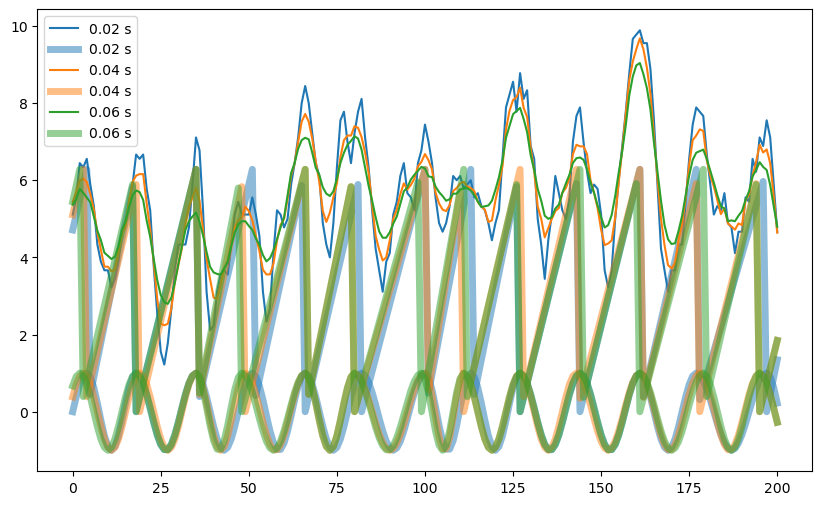

In [162]:
fig, axes = plt.subplots(1,1,figsize = (10,6))

ind = 0
for window in [0.02, 0.04, 0.06]:
    mua_smooth = smoothen_mua(mua_xr, moving_ave_window = window)

    theta_mua_xr = get_theta_from_mua(mua_xr, window_size = window)

    (t0,t1) = (mua_smooth.time[0].item() + 102, mua_smooth.time[0].item() + 104)
    
    mua_subset = mua_smooth.sel(
        time=mua_smooth.time[np.logical_and(
            mua_smooth.time>=t0,
            mua_smooth.time<=t1)])
    mua_array = mua_subset.to_array()

    theta_subset = theta_mua_xr.sel(
        time=theta_mua_xr.time[np.logical_and(
            mua_smooth.time>=t0,
            mua_smooth.time<=t1)]
    )
    theta_array = theta_subset.to_array()
    
    axes.plot(mua_array.T, label = str(window)+" s", color = "C"+str(ind))
    axes.plot(theta_array.T[:,0],label = str(window)+" s", color = "C"+str(ind),alpha = 0.5, linewidth = 5)

    # phase
    axes.plot(theta_array.T[:,2], color = "C"+str(ind),alpha = 0.5, linewidth = 5)
    ind += 1
plt.legend()

In [152]:
theta_array.shape

(3, 201)

In [ ]:
# form binned spikes for each neuron
# make MUA
# make theta from MUA
# save theta xr

In [54]:
nwb_copy_file_name = "julio20230805_.nwb"
session_name = "02_Seq2Session1"

In [67]:
key = {"nwb_file_name": nwb_copy_file_name,
       "sorter":"mountainsort4",
       "epoch":int(session_name[:2]),
       "curation_id":1}

cell_type_pd = pd.DataFrame((SingleUnit() & key).fetch1("cell_type_pd"))
sort_groups = np.unique([ind[0] for ind in cell_type_pd.index])

nwb_units_all = {}
for sort_group_id in sort_groups:
    nwb_units = electrode_unit(nwb_copy_file_name,session_name,sort_group_id,curation_id = 1)
    nwb_units_all[sort_group_id] = nwb_units

print("sort groups: ",sort_groups)

In [58]:
#nwb_units_all[0]

In [27]:
bin_size = 10 * pq.ms

In [60]:
nwb_unit = nwb_units_all[e].loc[u]
np.sum(np.diff(nwb_unit.obs_intervals,axis=1)) / 60

39.75978415807088

In [ ]:
# restrict to maze session

In [19]:
spike_trains = []


for u in nwb_units_all[e].index:
    nwb_unit = nwb_units_all[e].loc[u]

    spike_times = nwb_unit.spike_times * pq.s
    sort_interval = nwb_unit.sort_interval.ravel()
    t_start, t_stop = sort_interval
    
    # Create a SpikeTrain object
    spike_train_obj = neo.SpikeTrain(spike_times, t_start = t_start, t_stop = t_stop)
    spike_trains.append(spike_train_obj)

In [20]:
binned_spiketrains = BinnedSpikeTrain(
        spike_trains,
        bin_size=bin_size)

# spike count
binned_spiketrains_np = binned_spiketrains.to_array() # number of cells x number of timestamps

# Get the time bins
binned_spiketrains_t = binned_spiketrains.bin_centers

In [26]:
# form xarray
from ripple_detection.core import get_multiunit_population_firing_rate


In [32]:
mua = get_multiunit_population_firing_rate(binned_spiketrains_np.T,
                                             sampling_frequency = 100, smoothing_sigma=0.03)

In [73]:
binned_spiketrains_t

array([1.66612682e+09, 1.66612682e+09, 1.66612682e+09, ...,
       1.66612717e+09, 1.66612717e+09, 1.66612717e+09]) * s

In [41]:
t1

60000

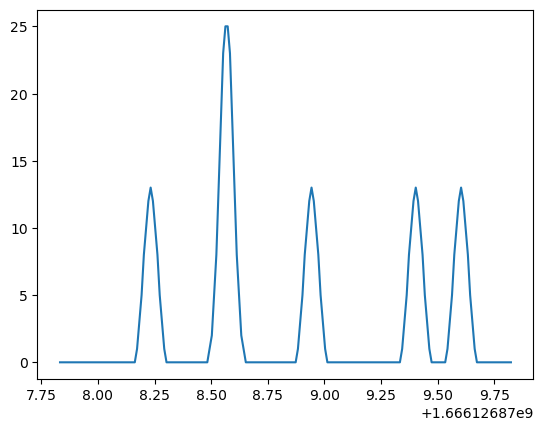

In [43]:
t1= 10*60*10
t2=t1+100*2
plt.plot(binned_spiketrains_t[t1:t2], mua[t1:t2])

In [22]:
binned_spiketrains_np.shape

(5, 35421)

In [42]:
binned_spiketrains_t[2] - binned_spiketrains_t[1]

array(0.00999999) * s

In [25]:
len(binned_spiketrains_t)

35421